# CAT TRAKING


In [ ]:
# pylint: disable=all
# type: ignore

import cv2
import numpy as np
import matplotlib.pyplot as plt

Reproduciendo video en una ventana externa... Presiona 'q' o 'Q' en la ventana de OpenCV para pararlo anticipadamente.
Video procesado exitosamente.


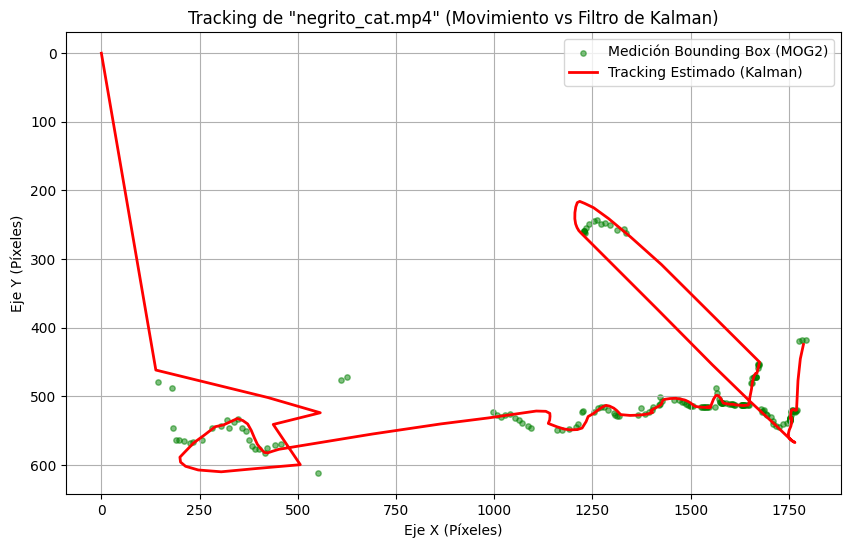

In [12]:
# pylint: disable=all
# type: ignore

# 1. Configurar la captura de video
video_path = "negrito_cat.mp4"  # Asegúrate de que el video está en la misma carpeta que el notebook
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(
        f"Error al abrir el video '{video_path}'. Verifica que el archivo exista en la misma ruta."
    )
else:
    # 2. Configurar el sustractor de fondo para detección de movimiento (MOG2)
    fgbg = cv2.createBackgroundSubtractorMOG2(
        history=500, varThreshold=50, detectShadows=True
    )

    # 3. Inicializar el Filtro de Kalman
    kf = cv2.KalmanFilter(4, 2)
    kf.transitionMatrix = np.array(
        [[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], np.float32
    )
    kf.measurementMatrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], np.float32)
    kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1.5
    kf.errorCovPost = np.eye(4, dtype=np.float32)

    measured_states = []
    estimated_states = []

    window_name = "Tracking del gatito - Presiona 'Q' para salir"
    # Configurar la ventana para que sea redimensionable temporalmente si el video es muy grande
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    print(
        "Reproduciendo video en una ventana externa... Presiona 'q' o 'Q' en la ventana de OpenCV para pararlo anticipadamente."
    )
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Preprocesamiento: escala de grises y difuminado
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (21, 21), 0)

        # Máscara de movimiento
        fgmask = fgbg.apply(gray)
        _, fgmask = cv2.threshold(fgmask, 200, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, kernel)
        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(
            fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        measurement = None

        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) > 500:
                x, y, w, h = cv2.boundingRect(largest_contour)
                cx, cy = x + w / 2.0, y + h / 2.0
                measurement = np.array([[np.float32(cx)], [np.float32(cy)]])
                measured_states.append((cx, cy))

                # --- Dibujar el bounding box (verde) ---
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.circle(frame, (int(cx), int(cy)), 4, (0, 255, 0), -1)

        # Predicción y Corrección
        predicted = kf.predict()
        if measurement is not None:
            estimated = kf.correct(measurement)
        else:
            estimated = predicted

        est_x, est_y = float(estimated[0][0]), float(estimated[1][0])
        estimated_states.append((est_x, est_y))

        # --- Dibujar la predicción y trayectoria de Kalman (rojo) ---
        cv2.circle(frame, (int(est_x), int(est_y)), 4, (0, 0, 255), -1)
        for i in range(1, len(estimated_states)):
            pt1 = (int(estimated_states[i - 1][0]), int(estimated_states[i - 1][1]))
            pt2 = (int(estimated_states[i][0]), int(estimated_states[i][1]))
            cv2.line(frame, pt1, pt2, (0, 0, 255), 2)

        # --- Mostrar el video con OpenCV ---
        cv2.imshow(window_name, frame)

        # Esperar 30ms. Si el usuario presiona la 'q', se rompe el ciclo.
        if cv2.waitKey(30) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()  # Es importante cerrar las ventanas de OpenCV
    print("Video procesado exitosamente.")

    # Graficar la trayectoria final
    if estimated_states:
        m_x = [p[0] for p in measured_states]
        m_y = [p[1] for p in measured_states]
        e_x = [p[0] for p in estimated_states]
        e_y = [p[1] for p in estimated_states]

        plt.figure(figsize=(10, 6))
        if m_x and m_y:
            plt.scatter(
                m_x, m_y, c="g", s=15, alpha=0.5, label="Medición Bounding Box (MOG2)"
            )
        plt.plot(e_x, e_y, "r-", linewidth=2, label="Tracking Estimado (Kalman)")

        plt.gca().invert_yaxis()
        plt.title('Tracking de "negrito_cat.mp4" (Movimiento vs Filtro de Kalman)')
        plt.xlabel("Eje X (Píxeles)")
        plt.ylabel("Eje Y (Píxeles)")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("No se calcularon estados.")